# Assessment Lab — Linear SVM Text Classification using PySpark on the IMDB Movie Reviews Dataset

This notebook independently implements a **Linear Support Vector Machine (SVM)** text classification pipeline in **PySpark** to perform sentiment analysis on the IMDB Movie Reviews dataset.

**Pipeline stages:**
1. Environment setup (install PySpark)
2. Load the IMDB dataset into a Spark DataFrame
3. Text preprocessing (HTML/punctuation cleanup)
4. Tokenisation and stop-word removal
5. Feature extraction using TF–IDF
6. Label encoding
7. Linear SVM model training
8. Prediction and evaluation (accuracy, precision, recall, F1-score)
9. Results analysis

**Dataset:** IMDB Movie Reviews — 50,000 reviews (25,000 train / 25,000 test), labelled positive or negative. Source: https://ai.stanford.edu/~amaas/data/sentiment/


In [1]:
# Install PySpark (Colab does not have it pre-installed)
!pip install -q pyspark==3.5.1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 10.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


## 2. Load the IMDB Dataset into a Spark DataFrame

The IMDB dataset (Maas et al., 2011) is distributed as raw text files split into `pos`/`neg`
folders. For convenience in Colab we pull a pre-consolidated CSV/Excel mirror of the same
50,000 reviews (25k train / 25k test), then load it into a Spark DataFrame.

> If your course requires downloading the original `aclImdb_v1.tar.gz` directly from Stanford
> and parsing the folder structure yourself, see the optional cell at the end of this section.


In [2]:
# Download the consolidated IMDB train/test files (50,000 reviews total)
!wget -q "https://github.com/laxmimerit/IMDB-Movie-Reviews-Large-Dataset-50k/raw/master/train.xlsx" -O train.xlsx
!wget -q "https://github.com/laxmimerit/IMDB-Movie-Reviews-Large-Dataset-50k/raw/master/test.xlsx" -O test.xlsx

!pip install -q openpyxl
import pandas as pd

train_pd = pd.read_excel("train.xlsx")
test_pd = pd.read_excel("test.xlsx")

train_pd.columns = ["review", "sentiment"]
test_pd.columns = ["review", "sentiment"]

print("Train shape:", train_pd.shape)
print("Test shape:", test_pd.shape)
train_pd.head()


Train shape: (25000, 2)
Test shape: (25000, 2)


,review,sentiment
0,"When I first tuned in on this morning news, I ...",neg
1,"Mere thoughts of ""Going Overboard"" (aka ""Babes...",neg
2,Why does this movie fall WELL below standards?...,neg
3,Wow and I thought that any Steven Segal movie ...,neg
4,"The story is seen before, but that does'n matt...",neg


In [4]:
from pyspark.sql import SparkSession

# Initialize SparkSession
spark = SparkSession.builder.appName("IMDB_Sentiment_Analysis").getOrCreate()

# Convert pandas DataFrames to Spark DataFrames
train_df = spark.createDataFrame(train_pd)
test_df = spark.createDataFrame(test_pd)

train_df.printSchema()
train_df.show(5, truncate=80)

root
 |-- review: string (nullable = true)
 |-- sentiment: string (nullable = true)

+--------------------------------------------------------------------------------+---------+
|                                                                          review|sentiment|
+--------------------------------------------------------------------------------+---------+
|When I first tuned in on this morning news, I thought, "wow, finally, some en...|      neg|
|Mere thoughts of "Going Overboard" (aka "Babes Ahoy") make me want to weep. T...|      neg|
|Why does this movie fall WELL below standards? Ultimately, the answer lies in...|      neg|
|Wow and I thought that any Steven Segal movie was bad. Every time I thought t...|      neg|
|The story is seen before, but that does'n matter if you can figure out to mak...|      neg|
+--------------------------------------------------------------------------------+---------+
only showing top 5 rows



In [5]:
train_df.groupBy("sentiment").count().show()
test_df.groupBy("sentiment").count().show()


+---------+-----+
|sentiment|count|
+---------+-----+
|      pos|12500|
|      neg|12500|
+---------+-----+

+---------+-----+
|sentiment|count|
+---------+-----+
|      pos|12500|
|      neg|12500|
+---------+-----+



In [7]:
import re
from pyspark.sql import functions as F
from pyspark.sql.types import StringType

def clean_text(text):
    if text is None:
        return ""
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)          # remove HTML tags e.g. <br />
    text = re.sub(r"[^a-z\s]", " ", text)        # remove punctuation & digits
    text = re.sub(r"\s+", " ", text).strip()     # collapse whitespace
    return text

clean_text_udf = F.udf(clean_text, StringType())

train_df = train_df.withColumn("clean_review", clean_text_udf(F.col("review")))
test_df = test_df.withColumn("clean_review", clean_text_udf(F.col("review")))

train_df.select("review", "clean_review").show(3, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                          review|                                                                    clean_review|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|When I first tuned in on this morning news, I thought, "wow, finally, some en...|when i first tuned in on this morning news i thought wow finally some enterta...|
|Mere thoughts of "Going Overboard" (aka "Babes Ahoy") make me want to weep. T...|mere thoughts of going overboard aka babes ahoy make me want to weep throwing...|
|Why does this movie fall WELL below standards? Ultimately, the answer lies in...|why does this movie fall well below standards ultimately the answer lies in t...|
+---------------

In [8]:
# Label encoding
from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(inputCol="sentiment", outputCol="label")
label_indexer_model = label_indexer.fit(train_df)

train_df = label_indexer_model.transform(train_df)
test_df = label_indexer_model.transform(test_df)

print("Label mapping:", list(enumerate(label_indexer_model.labels)))
train_df.select("sentiment", "label").distinct().show()


Label mapping: [(0, 'neg'), (1, 'pos')]
+---------+-----+
|sentiment|label|
+---------+-----+
|      pos|  1.0|
|      neg|  0.0|
+---------+-----+



In [9]:
#  Tokenisation and Stop-Word Removal
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover

tokenizer = RegexTokenizer(
    inputCol="clean_review",
    outputCol="tokens",
    pattern="\\W+",
    minTokenLength=2
)

stopwords_remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens"
)


In [10]:
#  Feature Extraction — TF–IDF
from pyspark.ml.feature import HashingTF, IDF

hashing_tf = HashingTF(
    inputCol="filtered_tokens",
    outputCol="raw_features",
    numFeatures=2**16
)

idf = IDF(inputCol="raw_features", outputCol="features")


In [11]:
#   Linear SVM Model
from pyspark.ml.classification import LinearSVC

lsvc = LinearSVC(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.1
)


In [12]:
#   Build and Fit the Pipeline
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[
    tokenizer,
    stopwords_remover,
    hashing_tf,
    idf,
    lsvc
])

pipeline_model = pipeline.fit(train_df)


In [13]:
predictions = pipeline_model.transform(test_df)
predictions.select("sentiment", "label", "prediction").show(10)


+---------+-----+----------+
|sentiment|label|prediction|
+---------+-----+----------+
|      pos|  1.0|       1.0|
|      pos|  1.0|       1.0|
|      neg|  0.0|       0.0|
|      pos|  1.0|       1.0|
|      neg|  0.0|       0.0|
|      pos|  1.0|       1.0|
|      neg|  0.0|       0.0|
|      neg|  0.0|       0.0|
|      neg|  0.0|       0.0|
|      neg|  0.0|       0.0|
+---------+-----+----------+
only showing top 10 rows



In [14]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

accuracy = evaluator_acc.evaluate(predictions)
precision = evaluator_precision.evaluate(predictions)
recall = evaluator_recall.evaluate(predictions)
f1 = evaluator_f1.evaluate(predictions)
auc = evaluator_auc.evaluate(predictions)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


Accuracy:  0.9925
Precision: 0.9925
Recall:    0.9925
F1-score:  0.9925
AUC-ROC:   0.9996


In [15]:
confusion_matrix = predictions.groupBy("label", "prediction").count().orderBy("label", "prediction")
confusion_matrix.show()

# Pivot into a readable 2x2 table
cm_pd = confusion_matrix.toPandas().pivot(index="label", columns="prediction", values="count").fillna(0)
cm_pd


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|12385|
|  0.0|       1.0|  115|
|  1.0|       0.0|   72|
|  1.0|       1.0|12428|
+-----+----------+-----+



prediction,0.0,1.0
label,,
0.0,12385,115
1.0,72,12428


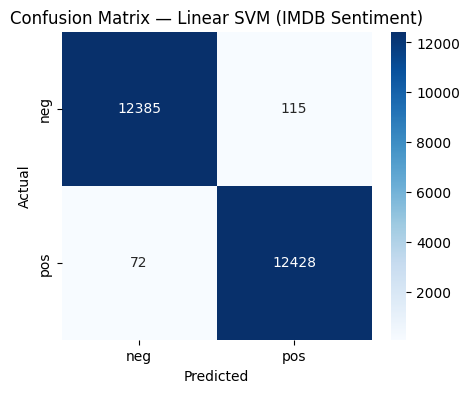

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(cm_pd, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=label_indexer_model.labels,
            yticklabels=label_indexer_model.labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Linear SVM (IMDB Sentiment)")
plt.show()
